Plot Charts

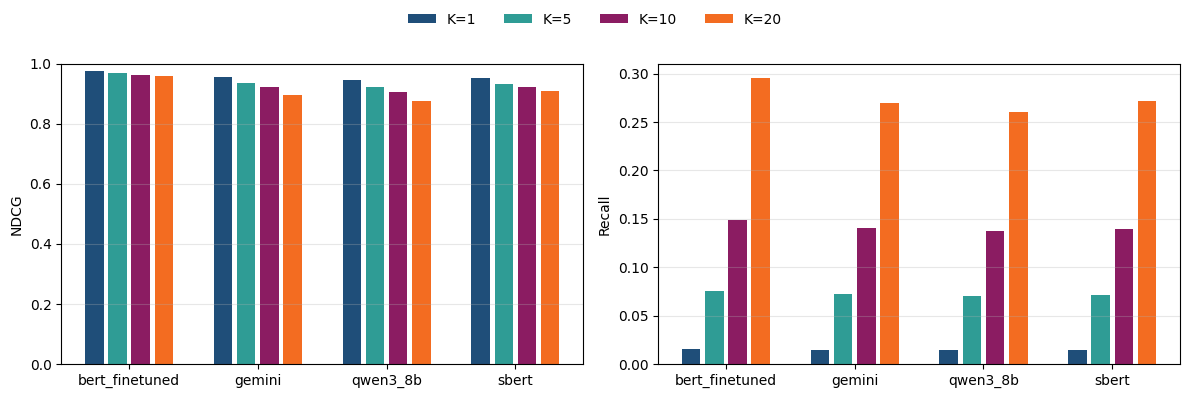

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# فایل نتایج
XLSX = "hybrid_rrf_summary.xlsx"
SHEET = "Summary"

K_LIST = [1, 5, 10, 20]

# خواندن داده
df = pd.read_excel(XLSX, sheet_name=SHEET, engine="openpyxl")

# فقط cosine
df = df[df["metric"].astype(str).str.lower() == "cosine"].copy()
df["K"] = df["K"].astype(int)
df = df[df["K"].isin(K_LIST)]

# pivot tables
pivot_ndcg = df.pivot_table(
    index="embedding",
    columns="K",
    values="ndcg@K",
    aggfunc="mean"
).sort_index()

pivot_recall = df.pivot_table(
    index="embedding",
    columns="K",
    values="recall@K",
    aggfunc="mean"
).sort_index()

embeddings = pivot_ndcg.index.tolist()
x = np.arange(len(embeddings))
bar_w = 0.18

colors = ["#1f4e79", "#2f9c95", "#8b1c62", "#f36c21"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ---------- NDCG ----------
ax = axes[0]
for j, K in enumerate(K_LIST):
    ax.bar(
        x + (j - (len(K_LIST) - 1) / 2) * bar_w,
        pivot_ndcg[K].values,
        # width=bar_w,
        width=bar_w * 0.80,
        color=colors[j],
        label=f"K={K}"
    )

# ax.set_title("Hybrid RRF — NDCG@K (cosine)")
ax.set_ylabel("NDCG")
ax.set_xticks(x)
ax.set_xticklabels(embeddings, rotation=0, ha="center")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)

# ---------- Recall ----------
ax = axes[1]
for j, K in enumerate(K_LIST):
    ax.bar(
        x + (j - (len(K_LIST) - 1) / 2) * bar_w,
        pivot_recall[K].values,
        # width=bar_w,
        width=bar_w * 0.80,
        color=colors[j],
        label=f"K={K}"
    )

# ax.set_title("Hybrid RRF — Recall@K (cosine)")
ax.set_ylabel("Recall")
ax.set_xticks(x)
ax.set_xticklabels(embeddings, rotation=0, ha="center")
ax.grid(axis="y", alpha=0.3)

# legend مشترک
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

In [ ]:
FIG_NAME = "Hybrid1_RRF_Search_NDGC_Accuracy_cosine.png"

fig.savefig(
    FIG_NAME,
    dpi=600,              
    bbox_inches="tight"
)

print("Figure saved as:", FIG_NAME)

✅ Figure saved as: Hybrid1_RRF_Search_NDGC_Accuracy_cosine.png
